# 20 · Real-world data: SQL, cleaning, corporate actions and point-in-time joins

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/20_messy_data_and_sql.ipynb)

In practice most of a quant's time goes into data, not models. Vendor files arrive with duplicates, odd number
formats, decimal errors, gaps, ticker changes, splits, dividends, several currencies, and fundamentals that were only
published weeks after the period they describe. Get any of these wrong and every model downstream is wrong too.

The files in `data/messy/` contain all of these problems on purpose (simulated, for 10 fictional Swiss and European
stocks, 2015–2024). You will query them with **SQL**, clean them with **pandas**, and build a trustworthy dataset.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
import sqlite3
M = DATA + "messy/"
raw = pd.read_csv(M + "prices_raw.csv", dtype={"close": str})       # read prices as text first: never trust a vendor's types
actions = pd.read_csv(M + "corporate_actions.csv", parse_dates=["ex_date"])
changes = pd.read_csv(M + "ticker_changes.csv")
fx = pd.read_csv(M + "fx_rates.csv", parse_dates=["date"])
fund = pd.read_csv(M + "fundamentals.csv", parse_dates=["fiscal_year_end", "report_date"])
members = pd.read_csv(M + "index_membership.csv", parse_dates=["start_date", "end_date"])
print(raw.shape); print(raw.dtypes); raw.head()

(24661, 5)
date          str
ticker        str
close         str
volume      int64
currency      str
dtype: object


,date,ticker,close,volume,currency
0,2015-01-02,ALPN,60.38,41092,CHF
1,2015-01-02,BRGN,179.11,72430,CHF
2,2015-01-02,CRYS,25.14,236971,CHF
3,2015-01-02,DELT,74.49,37412,EUR
4,2015-01-02,EDLW,94.93,255141,CHF


## 1. SQL: the language every data team speaks
SQL queries tables in databases. Python ships with **SQLite**, so we can load the raw files into an in-memory database and query them exactly as you would a production database.

In [3]:
con = sqlite3.connect(":memory:")
raw.to_sql("prices", con, index=False)
actions.assign(ex_date=actions.ex_date.dt.strftime("%Y-%m-%d")).to_sql("actions", con, index=False)
fx.assign(date=fx.date.dt.strftime("%Y-%m-%d")).to_sql("fx", con, index=False)
q = lambda sql: pd.read_sql(sql, con)

# rows, first and last date per ticker
q("""
SELECT ticker, COUNT(*) AS n_rows, MIN(date) AS first_date, MAX(date) AS last_date, currency
FROM prices
GROUP BY ticker, currency
ORDER BY ticker
""")

,ticker,n_rows,first_date,last_date,currency
0,ALPN,2580,2015-01-02,2024-12-31,CHF
1,BRGN,2595,2015-01-02,2024-12-31,CHF
2,CRYS,2194,2015-01-02,2023-06-09,CHF
3,DELT,2585,2015-01-02,2024-12-31,EUR
4,EDLW,2594,2015-01-02,2024-12-31,CHF
5,FJRD,2589,2015-01-02,2024-12-31,USD
6,GLAC,1759,2018-03-01,2024-12-31,CHF
7,HELV,1030,2021-01-04,2024-12-31,CHF
8,HLVT,1554,2015-01-02,2021-01-01,CHF
9,IBEX,2590,2015-01-02,2024-12-31,EUR


Already three discoveries: `HLVT` stops and `HELV` starts on the same day (a ticker change), `CRYS` ends in 2023 (delisted) and `GLAC` starts in 2018 (IPO). Real universes change over time.

In [4]:
# duplicates: the same ticker and date more than once
q("""
SELECT ticker, date, COUNT(*) AS copies
FROM prices
GROUP BY ticker, date
HAVING COUNT(*) > 1
ORDER BY copies DESC, date
LIMIT 5
""")

,ticker,date,copies
0,IBEX,2015-06-15,2
1,ALPN,2015-06-24,2
2,EDLW,2015-07-24,2
3,JURA,2015-08-04,2
4,ALPN,2015-09-23,2


In [5]:
# window functions: the previous close for each row (the building block of returns)
q("""
SELECT ticker, date, close,
       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close
FROM prices
WHERE ticker = 'BRGN' AND date BETWEEN '2019-05-10' AND '2019-05-20'
""")

,ticker,date,close,prev_close
0,BRGN,2019-05-10,447.55,NaN
1,BRGN,2019-05-13,441.71,447.55
2,BRGN,2019-05-14,444.2,441.71
3,BRGN,2019-05-15,223.5,444.2
4,BRGN,2019-05-16,223.98,223.5
5,BRGN,2019-05-17,223.77,223.98
6,BRGN,2019-05-20,222.19,223.77


Look at 15 May 2019: the price roughly halves. A crash? No: a **2-for-1 split** (see `actions`). Raw price returns are wrong on such days.

In [6]:
# joining tables: prices of a EUR stock with the EUR/CHF rate on the same day
q("""
SELECT p.date, p.ticker, p.close, f.EURCHF, ROUND(CAST(p.close AS REAL) * f.EURCHF, 2) AS close_chf
FROM prices p
LEFT JOIN fx f ON p.date = f.date
WHERE p.ticker = 'DELT' AND p.date BETWEEN '2016-01-04' AND '2016-01-12'
""")

,date,ticker,close,EURCHF,close_chf
0,2016-01-04,DELT,71.45,1.0462,74.75
1,2016-01-05,DELT,72.45,1.0512,76.16
2,2016-01-06,DELT,73.67,1.0554,77.75
3,2016-01-07,DELT,73.91,1.0585,78.23
4,2016-01-08,DELT,74.95,1.0590,79.37
5,2016-01-11,DELT,74.75,1.0625,79.42
6,2016-01-12,DELT,75.07,1.0717,80.45


Some rows have no FX rate: the FX file has gaps. A plain join loses information; Section 5 fixes this with an **as-of join**.

### Exercise 1

Write a SQL query that returns the **average volume of JURA in 2020** (on the raw `prices` table). Store the number in `sql_avg_vol`.

<details><summary>Hint</summary>

`q("SELECT AVG(volume) AS v FROM prices WHERE ticker = 'JURA' AND date BETWEEN '2020-01-01' AND '2020-12-31'")['v'].iloc[0]`

</details>

In [7]:
# Your code here

In [8]:
check("20.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 20.2: not answered yet. Store your answer in `sql_avg_vol`.


## 2. Cleaning in pandas

### Exercise 2

Count the fully duplicated rows in `raw` and store the number in `n_dupes`.

<details><summary>Hint</summary>

`raw.duplicated().sum()`

</details>

In [9]:
# Your code here

In [10]:
check("20.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 20.1: not answered yet. Store your answer in `n_dupes`.


In [11]:
odd = raw[~raw["close"].fillna("").str.fullmatch(r"\d+(\.\d+)?")]
print(len(odd), "prices are not plain numbers, for example:"); print(odd.head(6))

138 prices are not plain numbers, for example:
           date ticker     close  volume currency
8    2015-01-02   JURA  1'157.34   44607      CHF
184  2015-01-30   JURA  1'124.22  199606      CHF
361  2015-02-27   JURA  1'114.34  285466      CHF
539  2015-03-27   JURA  1'197.49  384346      CHF
718  2015-04-24   JURA  1'086.75  190943      CHF
896  2015-05-22   JURA  1'069.14   48654      CHF


### Exercise 3

Write `parse_price(x)` that turns `"1'234.50"` into `1234.5`, `"45.3"` into `45.3`, strips spaces, and returns `np.nan` for blank or missing values.

<details><summary>Hint</summary>

Check for missing/blank first; then `float(str(x).replace("'", "").replace(" ", ""))`. Swiss formatting uses ' as the thousands separator.

</details>

In [12]:
# Your code here

In [13]:
check("20.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 20.3: not answered yet. Store your answer in `parse_price`.


In [14]:
def _parse(x):                                             # reference version so the notebook runs before Exercise 3
    if x is None or (isinstance(x, float) and np.isnan(x)) or str(x).strip() == "":
        return np.nan
    return float(str(x).replace("'", "").replace(" ", ""))

df = raw.drop_duplicates().copy()
df["close"] = df["close"].map(_parse)
df["date"] = pd.to_datetime(df["date"])
df["pid"] = df["ticker"].replace(dict(zip(changes.old_ticker, changes.new_ticker)))   # permanent identifier
print("missing prices after parsing:", df["close"].isna().sum())
df = df.dropna(subset=["close"]).sort_values(["pid", "date"])

missing prices after parsing: 8


### Bad ticks
A price typed with the decimal point in the wrong place shows up as a single-day jump of 100× that reverses the next day. Compare each price with the median of its neighbours.

In [15]:
ref = df.groupby("pid")["close"].transform(lambda c: c.rolling(5, center=True, min_periods=1).median())
bad = df[~(df["close"] / ref).between(0.2, 5)]
print("bad ticks found:"); print(bad[["date", "pid", "close"]].assign(neighbour_median=ref[bad.index].round(2)))
df = df[(df["close"] / ref).between(0.2, 5)]
print("clean rows:", len(df), "of", len(raw), "raw rows")

bad ticks found:
            date   pid    close  neighbour_median
5112  2017-03-14  DELT  13224.0            130.01
18931 2022-08-17  EDLW   3502.0             34.64
14298 2020-11-02  FJRD   2791.0             27.91
clean rows: 24590 of 24661 raw rows


Notice the centred window looks at the **next** days too. That is fine for cleaning history, but a live system can only
compare with the past: in production, flag the tick and confirm it the next day.

## 3. Corporate actions: from prices to total returns
An investor's return on day *t* includes dividends paid and is not affected by splits:
$$r_t = \frac{P_t \times \text{split ratio}_t + D_t}{P_{t-1}} - 1$$
If a vendor file is missing the ex-date row, apply the action to the next available day.

            price return  total return
date                                  
2019-05-13       -0.0130       -0.0130
2019-05-14        0.0056        0.0056
2019-05-15       -0.4968        0.0063
2019-05-16        0.0021        0.0021
2019-05-17       -0.0009       -0.0009


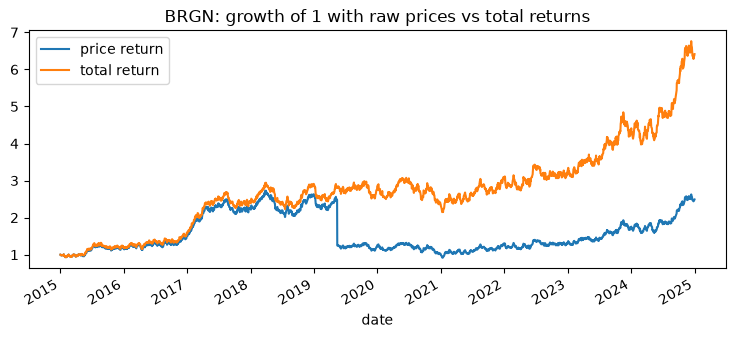

In [16]:
actions["pid"] = actions["ticker"].replace(dict(zip(changes.old_ticker, changes.new_ticker)))

def total_returns(pid):
    p = df[df.pid == pid].set_index("date")["close"]
    ratio = pd.Series(1.0, index=p.index); div = pd.Series(0.0, index=p.index)
    for _, a in actions[actions.pid == pid].iterrows():
        on = p.index[p.index >= a.ex_date]
        if len(on) == 0:
            continue
        if a.action == "split":
            ratio[on[0]] *= a.value
        else:
            div[on[0]] += a.value
    return (p * ratio + div) / p.shift(1) - 1

brgn = df[df.pid == "BRGN"].set_index("date")["close"]
comp = pd.DataFrame({"price return": brgn.pct_change(), "total return": total_returns("BRGN")})
print(comp.loc["2019-05-13":"2019-05-17"].round(4))
(1 + comp.fillna(0)).cumprod().plot(figsize=(9, 3.5), title="BRGN: growth of 1 with raw prices vs total returns"); plt.show()

### Exercise 4

Compute BRGN's **total return for calendar 2019** (from the last 2018 close to the last 2019 close), including the split and the dividend. Store it in `tr_brgn_2019`.

<details><summary>Hint</summary>

`(1 + total_returns('BRGN').loc['2019']).prod() - 1`

</details>

In [17]:
# Your code here

In [18]:
check("20.4");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 20.4: not answered yet. Store your answer in `tr_brgn_2019`.


## 4. Ticker changes
We mapped `HLVT` to `HELV` with a permanent identifier (`pid`). Without it, the history splits into two stocks, one that “disappears” and one that “IPOs”. Vendors provide permanent ids (PERMNO, ISIN, FIGI) for exactly this reason; always key your data on them.

## 5. Currencies: the as-of join
To convert a EUR price to CHF you need the FX rate **at that date or the most recent one before it**. `pd.merge_asof` does exactly that, and never looks forward.

In [19]:
eur = df[df.currency == "EUR"].sort_values("date")
plain = eur.merge(fx, on="date", how="left")
asof = pd.merge_asof(eur, fx.sort_values("date"), on="date", direction="backward")
print("rows without FX rate | plain join:", plain["EURCHF"].isna().sum(), "| as-of join:", asof["EURCHF"].isna().sum())
asof["close_chf"] = asof["close"] * asof["EURCHF"]
asof[["date", "pid", "close", "EURCHF", "close_chf"]].head()

rows without FX rate | plain join: 155 | as-of join: 0


,date,pid,close,EURCHF,close_chf
0,2015-01-02,DELT,74.49,1.0689,79.6224
1,2015-01-02,IBEX,151.78,1.0689,162.2376
2,2015-01-05,DELT,73.38,1.0721,78.6707
3,2015-01-05,IBEX,149.83,1.0721,160.6327
4,2015-01-06,IBEX,152.25,1.0704,162.9684


## 6. Point-in-time fundamentals: avoiding look-ahead
FY2019 earnings describe the year to 31 Dec 2019, but they were only **published in March 2020**. Joining on the fiscal year end lets your backtest trade on numbers nobody had yet.

In [20]:
fund["pid"] = fund["ticker"].replace(dict(zip(changes.old_ticker, changes.new_ticker)))
fund["eps"] = fund["net_income_m"] / fund["shares_m"]
days = df[df.pid == "BRGN"][["date", "pid", "close"]].sort_values("date")
f_b = fund[fund.pid == "BRGN"].sort_values("fiscal_year_end")
wrong = pd.merge_asof(days, f_b[["fiscal_year_end", "eps"]].rename(columns={"fiscal_year_end": "date"}), on="date")
right = pd.merge_asof(days, f_b[["report_date", "eps"]].rename(columns={"report_date": "date"}).sort_values("date"), on="date")
look = pd.DataFrame({"date": days.date, "eps by fiscal year end (look-ahead)": wrong.eps.values, "eps by report date (point-in-time)": right.eps.values}).set_index("date")
print(look.loc["2020-01-02":"2020-04-01"].iloc[::10].round(3))
print("\nBRGN share count changed with the 2019 split, so EPS is not comparable across it either:"); print(f_b[["fiscal_year_end", "report_date", "shares_m", "eps"]].round({"eps": 3}).tail(6))

            eps by fiscal year end (look-ahead)  \
date                                              
2020-01-02                               12.954   
2020-01-16                               12.954   
2020-01-30                               12.954   
2020-02-13                               12.954   
2020-02-27                               12.954   
2020-03-12                               12.954   
2020-03-26                               12.954   

            eps by report date (point-in-time)  
date                                            
2020-01-02                              14.989  
2020-01-16                              14.989  
2020-01-30                              14.989  
2020-02-13                              14.989  
2020-02-27                              14.989  
2020-03-12                              14.989  
2020-03-26                              12.954  

BRGN share count changed with the 2019 split, so EPS is not comparable across it either:
   fiscal

### Exercise 5

Which EPS figure for BRGN could an investor actually know on **14 February 2020**? Use the latest report with `report_date` on or before that day and store EPS (net income / shares) in `eps_pit`.

In [21]:
# Your code here

In [22]:
check("20.5");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 20.5: not answered yet. Store your answer in `eps_pit`.


## 7. Survivorship bias
Building an index from the stocks that exist today silently drops the ones that died. Use membership as of each date instead.

Annualised return:
point-in-time membership    0.0828
survivors only              0.0880
dtype: float64
Survivors-only index overstates the return by 0.53% a year


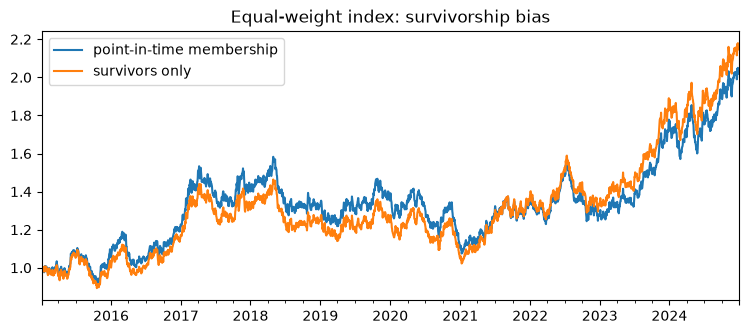

In [23]:
tr = pd.DataFrame({pid: total_returns(pid) for pid in df.pid.unique()})
alive_today = [p for p in tr.columns if pd.isna(members.set_index("ticker").loc[p, "end_date"])]
def in_index(date):
    m = members[(members.start_date <= date) & (members.end_date.isna() | (members.end_date >= date))]
    return list(m.ticker)
pit = pd.Series({d: tr.loc[d, in_index(d)].mean() for d in tr.index[1:]})
surv = tr[alive_today].iloc[1:].mean(axis=1)
out = pd.DataFrame({"point-in-time membership": pit, "survivors only": surv})
ann = out.mean() * 252
print("Annualised return:"); print(ann.round(4))
print(f"Survivors-only index overstates the return by {ann['survivors only'] - ann['point-in-time membership']:.2%} a year")
(1 + out.fillna(0)).cumprod().plot(figsize=(9, 3.5), title="Equal-weight index: survivorship bias"); plt.show()

One stock out of ten declined and was delisted, and the survivors-only index already looks better than what an
investor could actually have earned. In real equity databases thousands of companies delist, mostly after poor
performance (some leave through takeovers at a premium, which works the other way), and survivor-only backtests
typically overstate returns by a percentage point or more per year.

## 8. Put it together: a reusable pipeline and a data-quality report

In [24]:
def quality_report(raw, clean):
    r = raw.assign(pid=raw["ticker"].replace(dict(zip(changes.old_ticker, changes.new_ticker))))
    rep = pd.DataFrame({
        "raw rows": r.groupby("pid").size(),
        "duplicates": r[r.duplicated()].groupby("pid").size(),
        "clean rows": clean.groupby("pid").size(),
        "first date": clean.groupby("pid")["date"].min().dt.date,
        "last date": clean.groupby("pid")["date"].max().dt.date,
    }).fillna(0)
    bdays = clean.groupby("pid")["date"].agg(lambda d: len(pd.bdate_range(d.min(), d.max())))
    rep["coverage"] = (rep["clean rows"] / bdays).round(3)
    return rep
quality_report(raw, df)

,raw rows,duplicates,clean rows,first date,last date,coverage
pid,,,,,,
ALPN,2580,6,2574,2015-01-02,2024-12-31,0.987
BRGN,2595,8,2587,2015-01-02,2024-12-31,0.992
CRYS,2194,9,2184,2015-01-02,2023-06-09,0.992
DELT,2585,5,2579,2015-01-02,2024-12-31,0.989
EDLW,2594,9,2583,2015-01-02,2024-12-31,0.990
FJRD,2589,5,2581,2015-01-02,2024-12-31,0.990
GLAC,1759,2,1757,2018-03-01,2024-12-31,0.985
HELV,2584,4,2576,2015-01-02,2024-12-31,0.988
IBEX,2590,6,2584,2015-01-02,2024-12-31,0.991


**Your turn (no checker):**
1. Convert every stock's total returns to CHF (returns in CHF = (1 + local return) × (1 + FX return) − 1) and recompute the survivorship comparison in CHF.
2. Build a point-in-time **earnings yield** (EPS / price) signal for each stock and month, and check that no value is used before its report date.
3. Write the whole cleaning process as one function `build_clean_panel()` that returns a tidy table (date, pid, close, total return, return in CHF), so next month's file can be processed with one call. Notebook 21 shows how to test it.

---
## Solutions

In [25]:
n_dupes = int(raw.duplicated().sum()); print("1) duplicate rows:", n_dupes)
sql_avg_vol = q("SELECT AVG(volume) AS v FROM prices WHERE ticker = 'JURA' AND date BETWEEN '2020-01-01' AND '2020-12-31'")["v"].iloc[0]
print("2) JURA average volume 2020:", round(sql_avg_vol))

def parse_price(x):
    if x is None or (isinstance(x, float) and np.isnan(x)) or str(x).strip() == "":
        return np.nan
    return float(str(x).replace("'", "").replace(" ", ""))

tr_brgn_2019 = (1 + total_returns("BRGN").loc["2019"]).prod() - 1; print(f"4) BRGN total return 2019: {tr_brgn_2019:.2%}")
k = fund[(fund.pid == "BRGN") & (fund.report_date <= "2020-02-14")].sort_values("report_date").iloc[-1]
eps_pit = k.net_income_m / k.shares_m; print(f"5) EPS known on 2020-02-14: {eps_pit:.3f} (fiscal year {k.fiscal_year_end.year})")
check_all("20")

1) duplicate rows: 60
2) JURA average volume 2020: 205431
4) BRGN total return 2019: -2.43%
5) EPS known on 2020-02-14: 14.989 (fiscal year 2018)
✅ Exercise 20.1: correct.
✅ Exercise 20.2: correct.
✅ Exercise 20.3: correct.
✅ Exercise 20.4: correct.
✅ Exercise 20.5: correct.

5 of 5 exercises correct.
